# Used Car Price Prediction

## Problem Definition

The goal of this project is to predict the selling price of used cars
using vehicle characteristics such as mileage, year, brand, model,
exterior color, interior color, and other available features.

This is a regression problem because the target variable (price)
is a continuous numerical value.

### Data Understanding

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [181]:
df= pd.read_csv('car_web_scraped_dataset.csv')
df.head()

,name,year,miles,color,condition,price
0,Kia Forte,2022,"41,406 miles","Gray exterior, Black interior","No accidents reported, 1 Owner","$15,988"
1,Chevrolet Silverado 1500,2021,"15,138 miles","White exterior, Black interior","1 accident reported, 1 Owner","$38,008"
2,Toyota RAV4,2022,"32,879 miles","Silver exterior, Unknown interior","No accidents reported, 1 Owner","$24,988"
3,Honda Civic,2020,"37,190 miles","Blue exterior, Black interior","No accidents reported, 1 Owner","$18,998"
4,Honda Civic,2020,"27,496 miles","Black exterior, Black interior","No accidents reported, 1 Owner","$19,498"


In [182]:
df.shape

(2840, 6)

In [183]:
df.columns

Index(['name', 'year', 'miles', 'color', 'condition', 'price'], dtype='str')

In [184]:
df.dtypes

name           str
year         int64
miles          str
color          str
condition      str
price          str
dtype: object

In [185]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2840 entries, 0 to 2839
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       2840 non-null   str  
 1   year       2840 non-null   int64
 2   miles      2840 non-null   str  
 3   color      2840 non-null   str  
 4   condition  2840 non-null   str  
 5   price      2840 non-null   str  
dtypes: int64(1), str(5)
memory usage: 133.3 KB


In [186]:
df.describe()

,year
count,2840.000000
mean,2018.833803
std,3.557585
min,2000.000000
25%,2017.000000
50%,2020.000000
75%,2021.000000
max,2024.000000


In [187]:
df.nunique()

name          309
year           24
miles        2280
color          64
condition      25
price        1245
dtype: int64

In [188]:
df["name"].value_counts().head(20)

name
Toyota Corolla              114
Honda Civic                  97
Mercedes-Benz C-Class        76
Toyota Camry                 69
Ford F-150                   65
Toyota RAV4                  60
Subaru Outback               51
BMW 3 Series                 50
Jeep Wrangler                48
Honda Accord                 47
Kia Forte                    44
Mercedes-Benz GLC            43
Toyota Tacoma                43
Volkswagen Tiguan            42
BMW X3                       42
Chevrolet Silverado 1500     40
Subaru Forester              39
Nissan Sentra                38
Ford Escape                  38
Ford Explorer                37
Name: count, dtype: int64

In [189]:
df['color'].value_counts()

color
Black exterior, Black interior      576
White exterior, Black interior      522
Gray exterior, Black interior       350
Silver exterior, Black interior     200
White exterior, Gray interior       154
                                   ... 
Gray exterior, Blue interior          1
Unknown exterior, Beige interior      1
Purple exterior, Beige interior       1
Tan exterior, Gray interior           1
Yellow exterior, Yellow interior      1
Name: count, Length: 64, dtype: int64

In [190]:
df["condition"].value_counts()

condition
No accidents reported, 1 Owner     1575
No accidents reported, 2 Owners     426
1 accident reported, 1 Owner        236
1 accident reported, 2 Owners       157
No accidents reported, 3 Owners     152
1 accident reported, 3 Owners        58
2 accidents reported, 1 Owner        43
No accidents reported, 4 Owners      41
2 accidents reported, 2 Owners       30
2 accidents reported, 3 Owners       26
1 accident reported, 4 Owners        17
No accidents reported, 0 Owners      13
2 accidents reported, 4 Owners       12
No accidents reported, 5 Owners      11
1 accident reported, 5 Owners        10
3 accidents reported, 1 Owner         9
4 accidents reported, 3 Owners        5
3 accidents reported, 2 Owners        4
3 accidents reported, 3 Owners        3
No accidents reported, 7 Owners       3
5 accidents reported, 5 Owners        2
3 accidents reported, 4 Owners        2
No accidents reported, 8 Owners       2
2 accidents reported, 5 Owners        2
4 accidents reported, 2 Owners

In [191]:
df["miles"].head(20)

0     41,406 miles
1     15,138 miles
2     32,879 miles
3     37,190 miles
4     27,496 miles
5     29,026 miles
6      4,148 miles
7     57,602 miles
8     50,240 miles
9     56,766 miles
10    44,099 miles
11    11,140 miles
12     8,506 miles
13    38,760 miles
14    27,002 miles
15    22,850 miles
16    68,660 miles
17    55,079 miles
18    64,337 miles
19    83,424 miles
Name: miles, dtype: str

In [192]:
df["price"].head(20)

0     $15,988
1     $38,008
2     $24,988
3     $18,998
4     $19,498
5     $21,000
6     $20,998
7     $18,887
8     $19,498
9     $17,998
10    $30,998
11    $20,998
12    $22,597
13    $29,998
14    $39,998
15    $21,998
16    $17,998
17    $17,998
18    $19,598
19    $18,285
Name: price, dtype: str

In [193]:
df["price"].value_counts().head(20)

price
$19,998    51
$18,998    45
$20,998    42
$17,998    40
$16,998    37
$22,998    35
$23,998    33
$21,998    31
$29,998    30
$8,995     26
$15,998    25
$28,998    23
$24,998    22
$25,998    22
$27,998    20
$14,998    20
$35,998    20
$30,998    19
$31,998    19
$33,998    17
Name: count, dtype: int64

## Dataset Description

- Dataset Name: Used Cars Dataset
- Dataset Source: Kaggle
- Original Number of Rows: 2840
- Number of Columns: 6
- Rows After Removing Duplicates: 2312
- Target Variable: price

### Numerical Features
- year
- miles
- price

### Categorical Features
- name
- color
- condition

## Data Cleaning

The dataset was cleaned before applying machine learning models.

The cleaning process included:
- Handling missing values.
- Handling unknown categorical values.
- Cleaning numerical variables stored as text.
- Converting relevant columns into appropriate numerical formats.
- Checking potential outliers.
- Preparing categorical variables for encoding.

In [194]:
df_clean = df.copy()

In [195]:
df_clean["price"] = df_clean["price"].str.replace("$", "", regex=False)
df_clean["price"] = df_clean["price"].str.replace(",", "", regex=False)

In [196]:
df_clean["price"].head()

0    15988
1    38008
2    24988
3    18998
4    19498
Name: price, dtype: str

In [197]:
df_clean["price"] = pd.to_numeric(df_clean["price"])
df_clean["price"].dtype

dtype('int64')

In [198]:
df_clean["miles"] = df_clean["miles"].str.replace(",", "", regex=False)
df_clean["miles"] = df_clean["miles"].str.replace("miles", "", regex=False)
df_clean["miles"] = pd.to_numeric(df_clean["miles"])
df_clean["miles"].dtype

dtype('int64')

In [199]:
df_clean.dtypes

name           str
year         int64
miles        int64
color          str
condition      str
price        int64
dtype: object

In [200]:
df_clean.isnull().sum()

name         0
year         0
miles        0
color        0
condition    0
price        0
dtype: int64

## Missing Values

Missing values were checked using `isnull().sum()`.

The cleaned dataset contains no missing values in the main variables:
name, year, miles, color, condition, and price.

Therefore, no rows needed to be removed or filled because of missing
values at this stage.

In [201]:
df_clean.duplicated().sum()

np.int64(528)

In [202]:
df_clean[df_clean.duplicated(keep=False)].head(10)

,name,year,miles,color,condition,price
0,Kia Forte,2022,41406,"Gray exterior, Black interior","No accidents reported, 1 Owner",15988
1,Chevrolet Silverado 1500,2021,15138,"White exterior, Black interior","1 accident reported, 1 Owner",38008
23,BMW 7 Series,2015,57707,"White exterior, Black interior","No accidents reported, 3 Owners",27998
27,Mercedes-Benz C-Class,2021,18769,"Silver exterior, Unknown interior","No accidents reported, 1 Owner",29990
28,Honda CR-V,2020,74031,"Gray exterior, Gray interior","No accidents reported, 1 Owner",23998
32,Chrysler Pacifica,2018,73428,"White exterior, Black interior","No accidents reported, 2 Owners",19998
33,Volkswagen Tiguan,2020,28897,"White exterior, Black interior","1 accident reported, 1 Owner",20998
34,BMW 3 Series,2015,60478,"Black exterior, Black interior","1 accident reported, 2 Owners",16998
35,Porsche Cayenne,2020,44880,"Silver exterior, Black interior","No accidents reported, 3 Owners",43998
37,Nissan Sentra,2021,24044,"Black exterior, Black interior","No accidents reported, 1 Owner",20998


In [203]:
df_clean.shape

(2840, 6)

In [204]:
df_clean.drop_duplicates().shape

(2312, 6)

#### Handling Duplicate Records

 A total of 528 duplicate rows were identified and removed because they represent identical records and do not provide additional information. Keeping duplicate observations could give repeated records more weight during analysis and potentially bias the machine learning model.

 The dataset was reduced from 2,840 rows to 2,312 unique records.

In [205]:
df_clean.drop_duplicates(inplace=True)

In [206]:
df_clean

,name,year,miles,color,condition,price
0,Kia Forte,2022,41406,"Gray exterior, Black interior","No accidents reported, 1 Owner",15988
1,Chevrolet Silverado 1500,2021,15138,"White exterior, Black interior","1 accident reported, 1 Owner",38008
2,Toyota RAV4,2022,32879,"Silver exterior, Unknown interior","No accidents reported, 1 Owner",24988
3,Honda Civic,2020,37190,"Blue exterior, Black interior","No accidents reported, 1 Owner",18998
4,Honda Civic,2020,27496,"Black exterior, Black interior","No accidents reported, 1 Owner",19498
...,...,...,...,...,...,...
2835,Ford Escape,2013,98601,"Silver exterior, Unknown interior","2 accidents reported, 3 Owners",8995
2836,Mercedes-Benz R-Class,2009,120694,"Black exterior, Black interior","1 accident reported, 3 Owners",9495
2837,Mercedes-Benz GLC,2022,27894,"Gray exterior, Gray interior","No accidents reported, 2 Owners",29999
2838,Honda CR-V,2021,50220,"Gray exterior, Unknown interior","No accidents reported, 1 Owner",22992


In [207]:
df_clean=df_clean.reset_index(drop=True)
df_clean

,name,year,miles,color,condition,price
0,Kia Forte,2022,41406,"Gray exterior, Black interior","No accidents reported, 1 Owner",15988
1,Chevrolet Silverado 1500,2021,15138,"White exterior, Black interior","1 accident reported, 1 Owner",38008
2,Toyota RAV4,2022,32879,"Silver exterior, Unknown interior","No accidents reported, 1 Owner",24988
3,Honda Civic,2020,37190,"Blue exterior, Black interior","No accidents reported, 1 Owner",18998
4,Honda Civic,2020,27496,"Black exterior, Black interior","No accidents reported, 1 Owner",19498
...,...,...,...,...,...,...
2307,Ford Escape,2013,98601,"Silver exterior, Unknown interior","2 accidents reported, 3 Owners",8995
2308,Mercedes-Benz R-Class,2009,120694,"Black exterior, Black interior","1 accident reported, 3 Owners",9495
2309,Mercedes-Benz GLC,2022,27894,"Gray exterior, Gray interior","No accidents reported, 2 Owners",29999
2310,Honda CR-V,2021,50220,"Gray exterior, Unknown interior","No accidents reported, 1 Owner",22992


In [208]:
df_clean.describe()

,year,miles,price
count,2312.000000,2312.000000,2312.000000
mean,2018.873702,49896.590398,25841.419983
std,3.466794,36287.386865,13880.328572
min,2000.000000,25.000000,4395.000000
25%,2017.000000,23590.250000,17991.000000
50%,2020.000000,40703.000000,22999.000000
75%,2021.000000,69360.250000,30999.250000
max,2024.000000,307292.000000,252900.000000


### Visualizations 

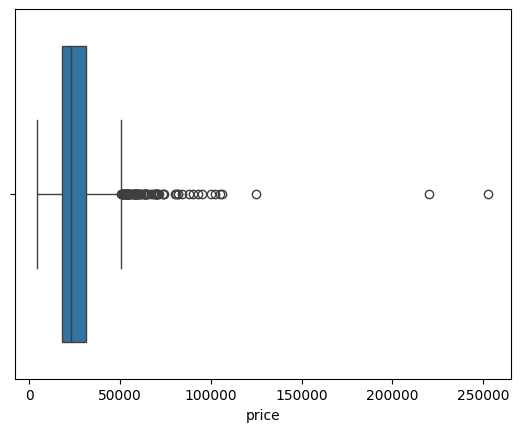

In [209]:
sns.boxplot(x=df_clean["price"])
plt.show()

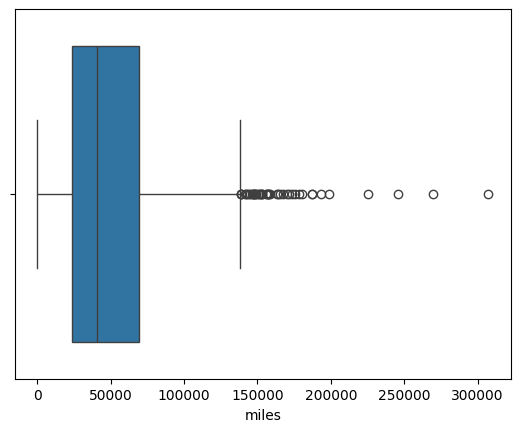

In [210]:
sns.boxplot(x=df_clean["miles"])
plt.show()

### Outlier Detection

Boxplots were used to identify potential outliers in car price and mileage.

Some extreme values were observed. These observations were not automatically
removed because they may represent real used-car listings rather than data
entry errors.

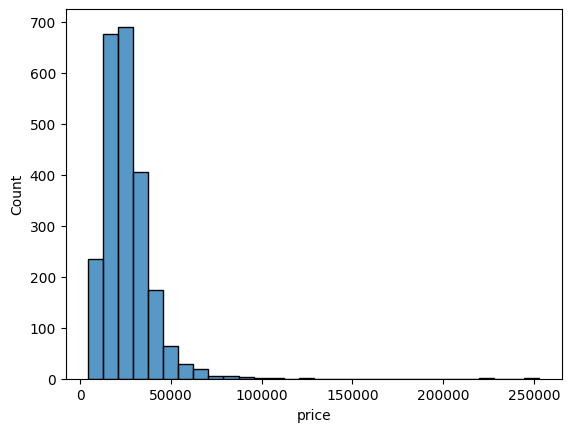

In [211]:
sns.histplot(data=df_clean, x="price", bins=30)
plt.show()

### Interpretation

The distribution of car prices is right-skewed. Most cars have
relatively moderate prices, while a smaller number of cars have
very high prices.

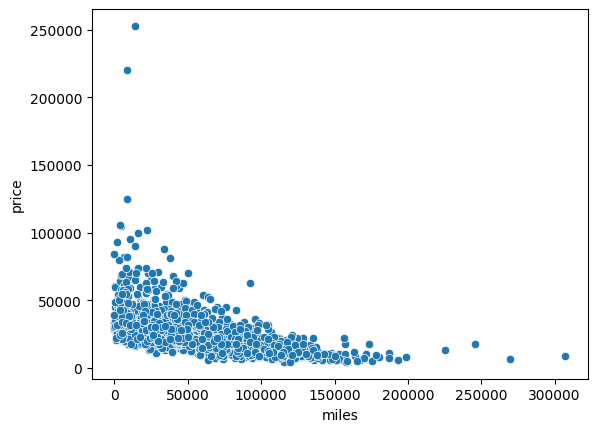

In [212]:
sns.scatterplot(data=df_clean, x="miles", y="price")
plt.show()

### Interpretation

The scatterplot shows a negative relationship between mileage and
car price. In general, cars with higher mileage tend to have lower
prices, although other factors also affect the price.

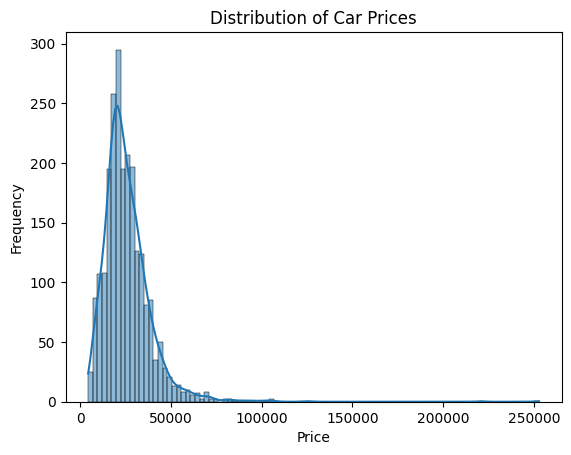

In [213]:
sns.histplot(df_clean["price"], kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The distribution of car prices is right-skewed. Most cars have
relatively moderate prices, while a smaller number of cars have
very high prices.

In [214]:
df_clean["condition"].unique()

<StringArray>
[ 'No accidents reported, 1 Owner',    '1 accident reported, 1 Owner',
   '1 accident reported, 3 Owners', 'No accidents reported, 3 Owners',
 'No accidents reported, 2 Owners',   '1 accident reported, 2 Owners',
 'No accidents reported, 5 Owners',  '3 accidents reported, 3 Owners',
   '3 accidents reported, 1 Owner',  '2 accidents reported, 4 Owners',
 'No accidents reported, 4 Owners',  '2 accidents reported, 3 Owners',
   '2 accidents reported, 1 Owner',   '1 accident reported, 4 Owners',
  '3 accidents reported, 2 Owners',  '2 accidents reported, 2 Owners',
 'No accidents reported, 0 Owners', 'No accidents reported, 7 Owners',
  '5 accidents reported, 5 Owners',  '3 accidents reported, 4 Owners',
  '4 accidents reported, 3 Owners',   '1 accident reported, 5 Owners',
 'No accidents reported, 8 Owners',  '2 accidents reported, 5 Owners',
  '4 accidents reported, 2 Owners']
Length: 25, dtype: str

In [215]:
df_clean["accidents"] = (
    df_clean["condition"]
    .str.extract(r'(\d+) accident')[0]
    .fillna(0)
    .astype(int)
)

In [216]:
df_clean["Owner"] = (
    df_clean["condition"]
    .str.extract(r'(\d+) Owner')[0]
    .fillna(0)
    .astype(int)
)

In [217]:
df_clean

,name,year,miles,color,condition,price,accidents,Owner
0,Kia Forte,2022,41406,"Gray exterior, Black interior","No accidents reported, 1 Owner",15988,0,1
1,Chevrolet Silverado 1500,2021,15138,"White exterior, Black interior","1 accident reported, 1 Owner",38008,1,1
2,Toyota RAV4,2022,32879,"Silver exterior, Unknown interior","No accidents reported, 1 Owner",24988,0,1
3,Honda Civic,2020,37190,"Blue exterior, Black interior","No accidents reported, 1 Owner",18998,0,1
4,Honda Civic,2020,27496,"Black exterior, Black interior","No accidents reported, 1 Owner",19498,0,1
...,...,...,...,...,...,...,...,...
2307,Ford Escape,2013,98601,"Silver exterior, Unknown interior","2 accidents reported, 3 Owners",8995,2,3
2308,Mercedes-Benz R-Class,2009,120694,"Black exterior, Black interior","1 accident reported, 3 Owners",9495,1,3
2309,Mercedes-Benz GLC,2022,27894,"Gray exterior, Gray interior","No accidents reported, 2 Owners",29999,0,2
2310,Honda CR-V,2021,50220,"Gray exterior, Unknown interior","No accidents reported, 1 Owner",22992,0,1


In [218]:
df_clean["exterior_color"] = df_clean["color"].str.split(", ").str[0]
df_clean["interior_color"] = df_clean["color"].str.split(", ").str[1]

In [219]:
df_clean[["color", "exterior_color", "interior_color"]].head()

,color,exterior_color,interior_color
0,"Gray exterior, Black interior",Gray exterior,Black interior
1,"White exterior, Black interior",White exterior,Black interior
2,"Silver exterior, Unknown interior",Silver exterior,Unknown interior
3,"Blue exterior, Black interior",Blue exterior,Black interior
4,"Black exterior, Black interior",Black exterior,Black interior


In [220]:
df_clean["exterior_color"] = df_clean["exterior_color"].str.replace(" exterior", "", regex=False)

df_clean["interior_color"] = df_clean["interior_color"].str.replace(" interior", "", regex=False)

In [221]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2312 entries, 0 to 2311
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2312 non-null   str   
 1   year            2312 non-null   int64 
 2   miles           2312 non-null   int64 
 3   color           2312 non-null   str   
 4   condition       2312 non-null   str   
 5   price           2312 non-null   int64 
 6   accidents       2312 non-null   int64 
 7   Owner           2312 non-null   int64 
 8   exterior_color  2312 non-null   object
 9   interior_color  2312 non-null   object
dtypes: int64(5), object(2), str(3)
memory usage: 180.8+ KB


In [222]:
df_clean.isnull().sum()

name              0
year              0
miles             0
color             0
condition         0
price             0
accidents         0
Owner             0
exterior_color    0
interior_color    0
dtype: int64

In [223]:
df_clean.head()

,name,year,miles,color,condition,price,accidents,Owner,exterior_color,interior_color
0,Kia Forte,2022,41406,"Gray exterior, Black interior","No accidents reported, 1 Owner",15988,0,1,Gray,Black
1,Chevrolet Silverado 1500,2021,15138,"White exterior, Black interior","1 accident reported, 1 Owner",38008,1,1,White,Black
2,Toyota RAV4,2022,32879,"Silver exterior, Unknown interior","No accidents reported, 1 Owner",24988,0,1,Silver,Unknown
3,Honda Civic,2020,37190,"Blue exterior, Black interior","No accidents reported, 1 Owner",18998,0,1,Blue,Black
4,Honda Civic,2020,27496,"Black exterior, Black interior","No accidents reported, 1 Owner",19498,0,1,Black,Black


In [224]:
df_clean = df_clean.drop(columns=["color", "condition"])
df_clean.head()

,name,year,miles,price,accidents,Owner,exterior_color,interior_color
0,Kia Forte,2022,41406,15988,0,1,Gray,Black
1,Chevrolet Silverado 1500,2021,15138,38008,1,1,White,Black
2,Toyota RAV4,2022,32879,24988,0,1,Silver,Unknown
3,Honda Civic,2020,37190,18998,0,1,Blue,Black
4,Honda Civic,2020,27496,19498,0,1,Black,Black


In [225]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]
X.head()

,name,year,miles,accidents,Owner,exterior_color,interior_color
0,Kia Forte,2022,41406,0,1,Gray,Black
1,Chevrolet Silverado 1500,2021,15138,1,1,White,Black
2,Toyota RAV4,2022,32879,0,1,Silver,Unknown
3,Honda Civic,2020,37190,0,1,Blue,Black
4,Honda Civic,2020,27496,0,1,Black,Black


In [226]:
from sklearn.model_selection import train_test_split

## Train/Test Split

The dataset was divided into training and testing sets using an
80/20 split.

The training set was used to train the models, while the testing set
was used to evaluate their performance on unseen data.

In [227]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [228]:
print(X["name"].nunique())
print(X["exterior_color"].nunique())
print(X["interior_color"].nunique())

309
14
11


In [229]:
X["name"].value_counts().describe()

count    309.000000
mean       7.482201
std       12.072448
min        1.000000
25%        1.000000
50%        3.000000
75%        8.000000
max       93.000000
Name: count, dtype: float64

In [230]:
X["name"].value_counts().head(20)

name
Toyota Corolla              93
Honda Civic                 82
Mercedes-Benz C-Class       60
Toyota Camry                57
Ford F-150                  53
Toyota RAV4                 50
Jeep Wrangler               43
BMW 3 Series                43
Subaru Outback              39
Kia Forte                   38
Honda Accord                38
Mercedes-Benz GLC           36
Toyota Tacoma               36
BMW X3                      35
Chevrolet Silverado 1500    34
Volkswagen Tiguan           34
Ford Escape                 32
Nissan Sentra               30
Chevrolet Malibu            29
Nissan Altima               28
Name: count, dtype: int64

In [231]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [232]:
categorical_features = ["name", "exterior_color", "interior_color"]


## Data Preprocessing

Categorical features were transformed using One-Hot Encoding so that
they could be used by the machine learning models.

The preprocessing was fitted on the training data and then applied
to the test data to avoid data leakage.

In [233]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [234]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [235]:
X_train_encoded.shape

(1849, 310)

In [236]:
X_test_encoded.shape

(463, 310)

In [237]:
for feature, categories in zip(
    categorical_features,
    preprocessor.named_transformers_["cat"].categories_
):
    print(feature, len(categories))

name 281
exterior_color 14
interior_color 11


### Models


In [238]:
from sklearn.linear_model import LinearRegression

In [239]:
model = LinearRegression()
model.fit(X_train_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](310,)","[-1225.61, 1194.74, -564.49,..., -0.15, -746.83, 656.89]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.701e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,310


In [240]:
y_pred = model.predict(X_test_encoded)
print(y_pred[:10])

[25794.36313084 32398.26268259  -169.38376968 33624.40575124
 28750.22472762 48808.40268942 21922.86041858 16281.6304452
 29020.28785086 20178.96462889]


In [241]:
from sklearn.metrics import mean_absolute_error
mae_lr = mean_absolute_error(y_test, y_pred)

In [242]:
mae_lr

5880.235953095622

In [243]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))

In [244]:
rmse_lr

np.float64(13331.56565518871)

In [245]:
from sklearn.metrics import r2_score
r2_lr = r2_score(y_test, y_pred)

r2_lr

0.3069166662018664

In [246]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mse_lr = mean_squared_error(y_test, y_pred)

In [247]:
mse_lr

177730642.81860715

In [248]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,26998,25794.363131
1,23988,32398.262683
2,17995,-169.383770
3,35037,33624.405751
4,252900,28750.224728
5,50723,48808.402689
6,22999,21922.860419
7,15995,16281.630445
8,21392,29020.287851
9,18998,20178.964629


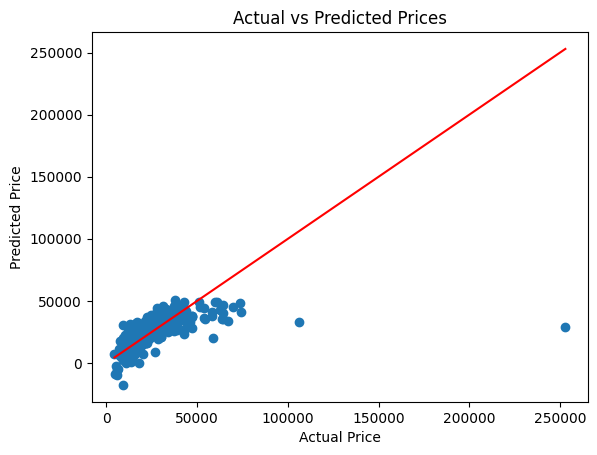

In [249]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

## Linear Regression

Linear Regression was used as the first regression model to predict
used car prices.

In [250]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [251]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [252]:
from sklearn.model_selection import GridSearchCV

k_values = [1, 3, 5, 7, 9, 11, 15, 20, 25, 30]

knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": k_values
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)

grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_["n_neighbors"]

print("Best K:", best_k)

Best K: 3


In [253]:
results_df

,K,MAE,MSE,RMSE,R2
0,1,6546.604752,2.155738e+08,14682.433053,0.159342
1,3,5927.089993,1.967518e+08,14026.822921,0.232741
2,5,6187.444060,1.993372e+08,14118.681067,0.222659
3,7,6271.860845,2.017516e+08,14203.928309,0.213244
4,9,6476.315335,2.081873e+08,14428.695796,0.188147
5,11,6656.433340,2.125985e+08,14580.758766,0.170945
6,15,6815.394816,2.189119e+08,14795.670419,0.146325
7,20,6988.108531,2.254534e+08,15015.104504,0.120816
8,25,7190.600000,2.301030e+08,15169.147548,0.102684
9,30,7318.882721,2.338566e+08,15292.371177,0.088046


In [254]:
best_knn_model = grid_search.best_estimator_

knn_pred = best_knn_model.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, knn_pred)
mse_knn = mean_squared_error(y_test, knn_pred)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, knn_pred)

print("Best K:", best_k)
print("Test MAE:", mae_knn)
print("Test MSE:", mse_knn)
print("Test RMSE:", rmse_knn)
print("Test R²:", r2_knn)

Best K: 3
Test MAE: 5927.0899928005765
Test MSE: 196751761.26949847
Test RMSE: 14026.822921442277
Test R²: 0.2327413862420239


## KNN Regression and Hyperparameter Selection

KNN Regression was trained using different values of K.

Five-fold cross-validation was performed on the training data to select
the best value of K based on Mean Absolute Error (MAE).

The selected K was then evaluated on the test set using MAE, MSE, RMSE, and R².

In [255]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regressor"],
    "MAE": [mae_lr, mae_knn],
    "MSE": [mse_lr, mse_knn],
    "RMSE": [rmse_lr, rmse_knn],
    "R2": [r2_lr, r2_knn]
})

results


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,5880.235953,1.777306e+08,13331.565655,0.306917
1,KNN Regressor,5927.089993,1.967518e+08,14026.822921,0.232741


### Model Comparison

Linear Regression achieved lower MAE, MSE, and RMSE and a higher R²
than KNN Regression.

Therefore, Linear Regression was selected as the final model.

## Model Comparison

The two regression models were compared using MAE, MSE, RMSE, and R².

Linear Regression was selected as the final model because it achieved
better overall performance than KNN Regression on the test set.

In [256]:
final_model = model

In [257]:
prediction = final_model.predict(X_test_encoded[0:1])

print("Predicted Price:", prediction[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 25794.363130844198
Actual Price: 26998


In [258]:
y_pred = final_model.predict(X_test_encoded)

residuals = y_test.values - y_pred

np.random.seed(42)
bootstrap_means = []

for i in range(1000):
    sample = np.random.choice(
        residuals,
        size=len(residuals),
        replace=True
    )
    
    bootstrap_means.append(sample.mean())
    
bootstrap_lower = np.percentile(bootstrap_means, 2.5)
bootstrap_upper = np.percentile(bootstrap_means, 97.5)

print("95% Bootstrap Confidence Interval for Mean Error:")
print("Lower:", bootstrap_lower)
print("Upper:", bootstrap_upper)

95% Bootstrap Confidence Interval for Mean Error:
Lower: -673.6629607891455
Upper: 1728.4099890551977


In [259]:
residuals = y_test.values - y_pred

In [260]:
residual_lower = np.percentile(residuals, 2.5)
residual_upper = np.percentile(residuals, 97.5)

In [261]:
prediction = final_model.predict(X_test_encoded[0:1])[0]

prediction_lower = prediction + residual_lower
prediction_upper = prediction + residual_upper


In [262]:
print("Predicted Price:")
print(f"${prediction:,.2f}")

print("\n95% Prediction Interval:")
print(f"Lower: ${prediction_lower:,.2f}")
print(f"Upper: ${prediction_upper:,.2f}")

Predicted Price:
$25,794.36

95% Prediction Interval:
Lower: $12,396.88
Upper: $45,994.09


## Bootstrap Analysis

Bootstrap resampling was used to estimate the uncertainty in the
mean prediction error.

A 95% confidence interval was calculated from the bootstrap
distribution.

In [263]:
import statsmodels.api as sm


## Statistical Analysis

### Statistical Question

Is mileage statistically associated with used car price?

### Null Hypothesis (H₀)

There is no statistically significant relationship between mileage
and car price.

β₁ = 0

### Alternative Hypothesis (H₁)

There is a statistically significant relationship between mileage
and car price.

β₁ ≠ 0

In [264]:
X_stat = df_clean[["miles"]]
y_stat = df_clean["price"]

In [265]:
X_stat = df_clean[["miles"]].astype(float)
y_stat = df_clean["price"].astype(float)

X_stat = sm.add_constant(X_stat)

stat_model = sm.OLS(y_stat, X_stat).fit()

print(stat_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     873.9
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          3.57e-163
Time:                        20:27:45   Log-Likelihood:                -24962.
No. Observations:                2312   AIC:                         4.993e+04
Df Residuals:                    2310   BIC:                         4.994e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.584e+04    418.207     85.701      0.0

In [266]:
coefficient = stat_model.params["miles"]
standard_error = stat_model.bse["miles"]
p_value = stat_model.pvalues["miles"]

confidence_interval = stat_model.conf_int().loc["miles"]

print("Coefficient:", coefficient)
print("Standard Error:", standard_error)
print("P-value:", p_value)
print("95% Confidence Interval:", confidence_interval.values)

Coefficient: -0.20039977793094593
Standard Error: 0.006778967890529709
P-value: 3.5667941119215904e-163
95% Confidence Interval: [-0.21369328 -0.18710628]


### Statistical vs Practical Significance

The relationship between mileage and price is statistically significant
because the p-value is much smaller than 0.05.

The estimated coefficient is approximately -0.2004, meaning that an
additional 1 mile is associated with an estimated decrease of about
$0.20 in price, based on this simple regression model.

Therefore, the relationship is statistically significant, and the
effect can also have practical relevance when considering differences
of thousands of miles.

In [267]:
import joblib

joblib.dump(final_model, "final_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [268]:
df_clean.to_csv("cleaned_car_data.csv", index=False)

## Conclusion

The goal of this project was to predict used car prices using machine
learning regression models.

After cleaning and exploring the dataset, two models were trained:
Linear Regression and KNN Regression.

Linear Regression achieved better performance on the test set based on
MAE, MSE, RMSE, and R², so it was selected as the final model.

The statistical analysis also showed a statistically significant negative
relationship between mileage and car price.

Finally, the selected model was used to generate a car price prediction
along with a 95% prediction interval.

The trained model and preprocessing component were also saved for future
use.